# 🧬 Dengue Clinical Symptom Synthetic Data Generator
DeBe Project

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arumpuri/dengue-dataset-normalized/dengue_dataset_normalization_tracking.csv
/kaggle/input/datasets/arumpuri/dengue-dataset-normalized/dengue_dataset_normalized.csv
/kaggle/input/datasets/arumpuri/dengue-dataset-normalized/normalization_report.txt


### 🎯 Purpose of This Notebook
The normalized hematological dataset contains laboratory values only — platelet counts, HCT, WBC, and red cell indices. While these are the gold standard for dengue severity assessment, real-world clinical triage never happens from lab values alone. A Puskesmas nurse observes:

* How many days has the patient been sick?
* Does the patient have a rash? What type?
* Are there warning signs like abdominal pain or mucosal bleeding?
* What is the fever pattern today compared to yesterday?

This notebook synthetically augments the hematological dataset with clinically realistic symptoms, disease phase information, and WHO severity classifications. Every generated feature is derived from evidence-based algorithms grounded in the WHO 2009 Dengue Guidelines — the same clinical standard the DeBe Triage Engine applies at inference time.

The result is a richer dataset that enables the DeBe LoRA adapter to reason across both laboratory and clinical dimensions simultaneously, mirroring how a trained clinician actually thinks.


###  🩺 Clinical Foundation: WHO Dengue Disease Phases 
Before any code runs, it is important to understand the biological model driving the data generation: Phase -> Days -> Key Laboratory Features -> Key Clinical Features

* Febrile -> 1–3 Days -> Mild leukopenia beginning -> High fever (38.5–40.5°C), severe headache, myalgia ("breakbone fever"), possible flushing rash

* Critical -> 4–7 Days -> Rapid platelet drop, rising HCT (plasma leakage) -> Fever defervescence, warning signs appear, high risk of severe dengue

* Recovery -> 8–10 Days -> Platelet recovery, HCT normalises -> Temperature returns to normal, fatigue, convalescent rash possible

Fever and platelet count move in opposite directions during the critical phase — fever drops while platelet danger peaks. This counterintuitive pattern is precisely why lab values alone are insufficient for triage, and why the DeBe system uses a multi-agent approach combining both.

###  📦 Loading the Normalized Dataset
The input is the output of Differential Count Normalization Pipeline Notebook : dengue_dataset_normalized.csv — 1,523 rows with all differential counts summing to exactly 100%. No further cleaning is needed before augmentation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("DENGUE CLINICAL SYMPTOM SYNTHETIC DATA GENERATOR")
print("="*80)
print(f"Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

# ============================================================================
# 1. LOAD NORMALIZED DATASET
# ============================================================================
print("\n" + "="*80)
print("1. LOADING NORMALIZED DATASET")
print("="*80)

df = pd.read_csv('/kaggle/input/datasets/arumpuri/dengue-dataset-normalized/dengue_dataset_normalization_tracking.csv')
print(f"✓ Dataset loaded: {df.shape}")
print(f"  Rows: {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")


DENGUE CLINICAL SYMPTOM SYNTHETIC DATA GENERATOR
Execution Time: 2026-02-20 17:08:52

1. LOADING NORMALIZED DATASET
✓ Dataset loaded: (1523, 25)
  Rows: 1,523
  Columns: 25


###  🏥 Clinical Knowledge Base
Two structured dictionaries define the clinical rules used throughout the generation:
Warning Signs (7 features) — from WHO 2009, these are the specific symptoms that escalate a case from routine dengue to "Dengue with Warning Signs," triggering mandatory hospital evaluation:
> abdominal_pain, persistent_vomiting, clinical_fluid_accumulation,
mucosal_bleeding, lethargy, liver_enlargement, hematocrit_increase

Severe Dengue Criteria (3 criteria) — plasma leakage causing shock, severe bleeding requiring transfusion, or severe organ impairment. Meeting any one of these triggers emergency hospitalisation.

In [3]:
# ============================================================================
# 2. CLINICAL KNOWLEDGE BASE
# ============================================================================
print("\n" + "="*80)
print("2. INITIALIZING CLINICAL KNOWLEDGE BASE")
print("="*80)

print("""
Dengue Clinical Phases and Symptoms (WHO Guidelines):

FEBRILE PHASE (Days 1-3):
- High fever (38-40°C)
- Headache, retro-orbital pain
- Myalgia, arthralgia
- Rash (sometimes)
- Mild bleeding (petechiae)

CRITICAL PHASE (Days 4-7):
- Fever defervescence
- Plasma leakage (↑ hematocrit, ↓ platelets)
- Warning signs appear
- Potential progression to severe dengue

RECOVERY PHASE (Days 8-10):
- Fluid reabsorption
- Platelet recovery
- Symptom resolution
- Bradycardia common
""")

# WHO Warning Signs
warning_signs = {
    'abdominal_pain': 'Severe abdominal pain or tenderness',
    'persistent_vomiting': 'Persistent vomiting (>3 episodes in 24h)',
    'clinical_fluid_accumulation': 'Clinical fluid accumulation (ascites, pleural effusion)',
    'mucosal_bleeding': 'Mucosal bleeding (epistaxis, gum bleeding)',
    'lethargy': 'Lethargy or restlessness',
    'liver_enlargement': 'Liver enlargement >2cm',
    'hematocrit_increase': 'Rapid hematocrit increase with platelet decrease'
}

# Severe dengue criteria
severe_criteria = {
    'severe_plasma_leakage': 'Shock or respiratory distress from plasma leakage',
    'severe_bleeding': 'Severe bleeding requiring transfusion',
    'severe_organ_impairment': 'Severe organ involvement (liver, CNS, heart)'
}

print("✓ Clinical knowledge base initialized")
print(f"  Warning signs: {len(warning_signs)}")
print(f"  Severe criteria: {len(severe_criteria)}")



2. INITIALIZING CLINICAL KNOWLEDGE BASE

Dengue Clinical Phases and Symptoms (WHO Guidelines):

FEBRILE PHASE (Days 1-3):
- High fever (38-40°C)
- Headache, retro-orbital pain
- Myalgia, arthralgia
- Rash (sometimes)
- Mild bleeding (petechiae)

CRITICAL PHASE (Days 4-7):
- Fever defervescence
- Plasma leakage (↑ hematocrit, ↓ platelets)
- Warning signs appear
- Potential progression to severe dengue

RECOVERY PHASE (Days 8-10):
- Fluid reabsorption
- Platelet recovery
- Symptom resolution
- Bradycardia common

✓ Clinical knowledge base initialized
  Warning signs: 7
  Severe criteria: 3


### ⚙️ Symptom Generation Algorithm Design
Nine generation functions are defined. Each follows the same design principle: laboratory values are the ground truth; symptoms are generated to be statistically consistent with those values.

> assign_day_of_illness(platelet, hct, result)

Maps lab patterns to disease timeline:

* Platelets < 100k AND HCT > 45% → Critical phase (Days 4–7) with probability weights
* Negative results → skewed toward early (Days 1–3) or late presentation (Days 8–10)
* All assignments use np.random.choice with explicit probability arrays, making the distribution auditable and reproducible
> generate_fever_pattern(day, result)

 Implements the classic dengue fever curve:

* Days 1–3: High fever 38.5–40.5°C
* Days 4–7: Defervescence 37.0–38.5°C ← critical clinical warning that dengue is worsening
* Days 8–10: Recovery 36.5–37.8°C
* Negative cases: Lower baseline 37.5–39.0°C
  
> generate_warning_signs(day, platelet, hct, result, wbc)

The most clinically important function. Uses a risk scoring model to determine the number and type of warning signs:

* Risk Score = 0
* IF Platelets < 50k: += 3
* IF Platelets < 100k: += 2 (exclusive)
* IF HCT > 47%: += 2
* IF Day 4–7: += 2
* IF WBC < 4k: += 1
* Score ≥ 5 → 2–4 warning signs (high risk)
* Score ≥ 3 → 1–2 warning signs (moderate risk)
* Score < 3 → 30% chance of 1 warning sign (low risk)

This neuro-symbolic design mirrors the DeBe application itself: structured rules compute the risk, and the language model explains the clinical significance.

> classify_who_severity(platelet, hct, warning_dict, result)

Applies the WHO 2009 four-category classification:

* negative result → not_dengue
* platelet < 50k + ≥3 signs → severe_dengue
* any warning sign present → dengue_with_warning_signs
* no warning signs → dengue_without_warning_signs

The raw Mendeley dataset has a minimum platelet count of 56,000 /μL and no cases meeting simultaneous platelet < 20k AND HCT > 50% criteria. As a result, the severe_dengue category produces 0 cases in this notebook. This is an accurate reflection of the dataset's severity range — the original data skews toward moderate DHF. Severe and critical cases are addressed deliberately in Notebook 4 through targeted synthetic augmentation.

In [4]:
# ============================================================================
# 3. DEFINE SYMPTOM GENERATION FUNCTIONS
# ============================================================================
print("\n" + "="*80)
print("3. DEFINING SYMPTOM GENERATION ALGORITHMS")
print("="*80)

def assign_day_of_illness(platelet_count, hct, result):
    """
    Assign day of illness based on hematological markers
    
    Logic:
    - Low platelets + high HCT → Critical phase (days 4-7)
    - Normal/mild changes → Febrile phase (days 1-3) or Recovery (days 8-10)
    - Negative results → Early phase (days 1-3)
    """
    if result == 'negative':
        # Negative results are likely early or late presentation
        return np.random.choice([1, 2, 3, 8, 9, 10], p=[0.3, 0.3, 0.2, 0.1, 0.05, 0.05])
    
    # Positive cases - determine phase by lab markers
    if platelet_count < 100000:  # Thrombocytopenia
        if hct > 45:  # Hemoconcentration
            # Critical phase
            return np.random.choice([4, 5, 6, 7], p=[0.2, 0.4, 0.3, 0.1])
        else:
            # Early critical or recovery
            return np.random.choice([3, 4, 7, 8], p=[0.2, 0.3, 0.3, 0.2])
    else:
        # Higher platelets - early or recovery phase
        if hct > 44:
            # Early febrile with some hemoconcentration
            return np.random.choice([2, 3, 4], p=[0.3, 0.5, 0.2])
        else:
            # Early febrile or recovery
            return np.random.choice([1, 2, 3, 8, 9], p=[0.2, 0.3, 0.3, 0.1, 0.1])

def generate_fever_pattern(day_of_illness, result):
    """Generate fever based on disease phase"""
    if result == 'negative':
        # Lower, variable fever
        return round(np.random.uniform(37.5, 39.0), 1)
    
    if day_of_illness <= 3:
        # High fever in febrile phase
        return round(np.random.uniform(38.5, 40.5), 1)
    elif day_of_illness <= 7:
        # Fever defervescence in critical phase
        return round(np.random.uniform(37.0, 38.5), 1)
    else:
        # Recovery - normal or slightly elevated
        return round(np.random.uniform(36.5, 37.8), 1)

def generate_headache(day_of_illness, result, fever):
    """Generate headache severity (0-10 scale)"""
    if result == 'negative':
        return np.random.choice([0, 1, 2, 3, 4], p=[0.3, 0.2, 0.2, 0.2, 0.1])
    
    if day_of_illness <= 3:
        # Severe headache in febrile phase
        return np.random.choice([5, 6, 7, 8, 9], p=[0.1, 0.2, 0.3, 0.3, 0.1])
    elif day_of_illness <= 7:
        # Moderate headache in critical phase
        return np.random.choice([3, 4, 5, 6], p=[0.3, 0.3, 0.3, 0.1])
    else:
        # Mild or no headache in recovery
        return np.random.choice([0, 1, 2, 3], p=[0.3, 0.3, 0.3, 0.1])

def generate_myalgia(day_of_illness, result):
    """Generate muscle pain severity (0-10 scale)"""
    if result == 'negative':
        return np.random.choice([0, 1, 2, 3], p=[0.4, 0.3, 0.2, 0.1])
    
    if day_of_illness <= 3:
        # Severe myalgia - "breakbone fever"
        return np.random.choice([6, 7, 8, 9, 10], p=[0.1, 0.2, 0.3, 0.3, 0.1])
    elif day_of_illness <= 7:
        # Moderate myalgia
        return np.random.choice([3, 4, 5, 6], p=[0.3, 0.3, 0.3, 0.1])
    else:
        # Minimal myalgia in recovery
        return np.random.choice([0, 1, 2, 3], p=[0.4, 0.3, 0.2, 0.1])

def generate_rash(day_of_illness, result):
    """Generate rash presence (binary + type)"""
    if result == 'negative':
        return 'none' if np.random.random() < 0.8 else 'non-specific'
    
    if day_of_illness <= 2:
        # Early flushing
        return 'flushing' if np.random.random() < 0.3 else 'none'
    elif day_of_illness <= 7:
        # Maculopapular rash in recovery from critical phase
        return 'maculopapular' if np.random.random() < 0.5 else 'none'
    else:
        # "Islands of white in sea of red" in late recovery
        return 'convalescent' if np.random.random() < 0.4 else 'none'

def generate_warning_signs(day_of_illness, platelet_count, hct, result, wbc):
    """
    Generate warning signs based on disease severity
    Returns dict of warning signs (binary)
    """
    warning_dict = {sign: 0 for sign in warning_signs.keys()}
    
    if result == 'negative':
        # Minimal warning signs
        if np.random.random() < 0.05:
            warning_dict[np.random.choice(list(warning_signs.keys()))] = 1
        return warning_dict
    
    # Calculate risk score
    risk_score = 0
    if platelet_count < 50000:
        risk_score += 3
    elif platelet_count < 100000:
        risk_score += 2
    
    if hct > 47:  # Male threshold
        risk_score += 2
    elif hct > 44:
        risk_score += 1
    
    if day_of_illness >= 4 and day_of_illness <= 7:
        risk_score += 2
    
    if wbc < 4000:
        risk_score += 1
    
    # Generate warning signs based on risk
    if risk_score >= 5:
        # High risk - multiple warning signs
        num_signs = np.random.choice([2, 3, 4], p=[0.3, 0.5, 0.2])
        signs_present = np.random.choice(list(warning_signs.keys()), 
                                         size=num_signs, replace=False)
        for sign in signs_present:
            warning_dict[sign] = 1
    elif risk_score >= 3:
        # Moderate risk - 1-2 warning signs
        num_signs = np.random.choice([1, 2], p=[0.6, 0.4])
        signs_present = np.random.choice(list(warning_signs.keys()), 
                                         size=num_signs, replace=False)
        for sign in signs_present:
            warning_dict[sign] = 1
    else:
        # Low risk - occasional warning signs
        if np.random.random() < 0.3:
            sign = np.random.choice(list(warning_signs.keys()))
            warning_dict[sign] = 1
    
    return warning_dict

def classify_who_severity(platelet_count, hct, warning_dict, result):
    """
    Classify dengue severity according to WHO criteria
    
    Categories:
    - Dengue without warning signs
    - Dengue with warning signs
    - Severe dengue
    """
    if result == 'negative':
        return 'not_dengue'
    
    # Count warning signs
    warning_count = sum(warning_dict.values())
    
    # Severe dengue criteria
    if platelet_count < 20000 and hct > 50:
        return 'severe_dengue'
    
    if platelet_count < 50000 and warning_count >= 3:
        return 'severe_dengue'
    
    # Dengue with warning signs
    if warning_count >= 1:
        return 'dengue_with_warning_signs'
    
    # Dengue without warning signs
    return 'dengue_without_warning_signs'

def generate_hospitalization_status(who_severity, age):
    """Determine if patient should be hospitalized"""
    if who_severity == 'severe_dengue':
        return 'hospitalized'
    elif who_severity == 'dengue_with_warning_signs':
        # Age factors into hospitalization decision
        if age < 15 or age > 60:
            return 'hospitalized' if np.random.random() < 0.8 else 'outpatient_monitoring'
        else:
            return 'hospitalized' if np.random.random() < 0.6 else 'outpatient_monitoring'
    elif who_severity == 'dengue_without_warning_signs':
        return 'outpatient' if np.random.random() < 0.9 else 'outpatient_monitoring'
    else:  # not_dengue
        return 'outpatient'

def generate_bleeding_manifestations(platelet_count, day_of_illness):
    """Generate bleeding symptoms based on platelet count"""
    bleeding_types = []
    
    if platelet_count < 50000:
        # High risk - multiple bleeding manifestations
        options = ['petechiae', 'gum_bleeding', 'epistaxis', 'menorrhagia', 'hematemesis']
        prob_bleeding = 0.8
        if np.random.random() < prob_bleeding:
            num_types = np.random.choice([1, 2, 3], p=[0.4, 0.4, 0.2])
            bleeding_types = list(np.random.choice(options, size=num_types, replace=False))
    elif platelet_count < 100000:
        # Moderate risk - minor bleeding
        options = ['petechiae', 'gum_bleeding', 'epistaxis']
        prob_bleeding = 0.5
        if np.random.random() < prob_bleeding:
            num_types = np.random.choice([1, 2], p=[0.7, 0.3])
            bleeding_types = list(np.random.choice(options, size=num_types, replace=False))
    else:
        # Low risk - occasional petechiae
        if np.random.random() < 0.2:
            bleeding_types = ['petechiae']
    
    return ','.join(bleeding_types) if bleeding_types else 'none'

print("✓ Symptom generation functions defined")
print("  Functions created: 9")



3. DEFINING SYMPTOM GENERATION ALGORITHMS
✓ Symptom generation functions defined
  Functions created: 9


###  🔄 Generating Synthetic Clinical Data
The generation loop processes all 1,523 rows sequentially. For each row:

1. Extracts key parameters (platelet, HCT, result, age, gender, WBC)
2. Calls each generation function in dependency order (day → fever → symptoms → warning signs → classification)
3. Appends all outputs to clinical_data dictionary

Random seed: np.random.seed(42) is set before the loop, guaranteeing identical outputs on every run — essential for reproducibility in a competition setting.
The result is 17 new columns merged with the original 19 to produce a 36-column enhanced dataset.

In [5]:
# ============================================================================
# 4. GENERATE SYNTHETIC CLINICAL DATA
# ============================================================================
print("\n" + "="*80)
print("4. GENERATING SYNTHETIC CLINICAL DATA")
print("="*80)

print("\nProcessing rows...")

# Set random seed for reproducibility
np.random.seed(42)

# Initialize new columns
clinical_data = {
    'day_of_illness': [],
    'fever_celsius': [],
    'headache_severity': [],
    'myalgia_severity': [],
    'retro_orbital_pain': [],
    'rash_type': [],
    'nausea_vomiting': [],
    'abdominal_pain': [],
    'persistent_vomiting': [],
    'clinical_fluid_accumulation': [],
    'mucosal_bleeding': [],
    'lethargy': [],
    'liver_enlargement': [],
    'hematocrit_increase': [],
    'bleeding_manifestations': [],
    'who_severity_classification': [],
    'hospitalization_status': []
}

# Generate data for each row
for idx, row in df.iterrows():
    if idx % 200 == 0:
        print(f"  Processing row {idx}/{len(df)}...")
    
    # Extract key parameters
    platelet_count = row['Total Platelet Count(/cumm)']
    hct = row['HCT(%)']
    result = row['Result']
    age = row['Age']
    wbc = row['Total WBC count(/cumm)']
    gender = row['Gender']
    
    # Generate temporal information
    day_of_illness = assign_day_of_illness(platelet_count, hct, result)
    clinical_data['day_of_illness'].append(day_of_illness)
    
    # Generate symptoms
    fever = generate_fever_pattern(day_of_illness, result)
    clinical_data['fever_celsius'].append(fever)
    
    headache = generate_headache(day_of_illness, result, fever)
    clinical_data['headache_severity'].append(headache)
    
    myalgia = generate_myalgia(day_of_illness, result)
    clinical_data['myalgia_severity'].append(myalgia)
    
    # Retro-orbital pain (correlated with headache)
    retro_orbital = 1 if (headache >= 5 and np.random.random() < 0.7) else 0
    clinical_data['retro_orbital_pain'].append(retro_orbital)
    
    rash = generate_rash(day_of_illness, result)
    clinical_data['rash_type'].append(rash)
    
    # GI symptoms
    nausea = 1 if (result == 'positive' and np.random.random() < 0.6) else 0
    clinical_data['nausea_vomiting'].append(nausea)
    
    # Generate warning signs
    warning_dict = generate_warning_signs(day_of_illness, platelet_count, hct, result, wbc)
    clinical_data['abdominal_pain'].append(warning_dict['abdominal_pain'])
    clinical_data['persistent_vomiting'].append(warning_dict['persistent_vomiting'])
    clinical_data['clinical_fluid_accumulation'].append(warning_dict['clinical_fluid_accumulation'])
    clinical_data['mucosal_bleeding'].append(warning_dict['mucosal_bleeding'])
    clinical_data['lethargy'].append(warning_dict['lethargy'])
    clinical_data['liver_enlargement'].append(warning_dict['liver_enlargement'])
    clinical_data['hematocrit_increase'].append(warning_dict['hematocrit_increase'])
    
    # Bleeding manifestations
    bleeding = generate_bleeding_manifestations(platelet_count, day_of_illness)
    clinical_data['bleeding_manifestations'].append(bleeding)
    
    # WHO severity classification
    who_severity = classify_who_severity(platelet_count, hct, warning_dict, result)
    clinical_data['who_severity_classification'].append(who_severity)
    
    # Hospitalization status
    hosp_status = generate_hospitalization_status(who_severity, age)
    clinical_data['hospitalization_status'].append(hosp_status)

# Create DataFrame with new features
clinical_df = pd.DataFrame(clinical_data)

# Combine with original data
df_enhanced = pd.concat([df, clinical_df], axis=1)

print(f"✓ Clinical data generation complete!")
print(f"  New features added: {len(clinical_data)}")


4. GENERATING SYNTHETIC CLINICAL DATA

Processing rows...
  Processing row 0/1523...
  Processing row 200/1523...
  Processing row 400/1523...
  Processing row 600/1523...
  Processing row 800/1523...
  Processing row 1000/1523...
  Processing row 1200/1523...
  Processing row 1400/1523...
✓ Clinical data generation complete!
  New features added: 17


###  ✅ Synthetic Data Quality Validation¶
Key validation checks confirm the generation algorithms produced clinically coherent patterns: Day of illness distribution (positive cases):

1. Days 2–3 dominate (febrile phase) — correct, as most patients present early
2. Days 4–7 are less frequent — correct, many critical-phase patients are already hospitalised before day 4
3. Days 8–10 are rare — correct, recovery patients rarely present for new clinical assessment
   
Fever pattern by phase (positive cases):
* Febrile phase (Days 1–3): 39.49°C ← high, as expected
* Critical phase (Days 4–7): 37.78°C ← defervescence confirmed ✓
* Recovery phase (Days 8–10): 37.16°C ← near-normal, as expected ✓
  
Warning signs by platelet count:
* Platelets < 100k: 2.09 average warning signs per patient
* Platelets ≥ 100k: 0.44 average warning signs per patient

The 4.75× difference confirms that warning signs are correctly correlated with thrombocytopenia — a core WHO clinical observation.

In [6]:
# ============================================================================
# 5. DATA QUALITY VALIDATION
# ============================================================================
print("\n" + "="*80)
print("5. VALIDATING SYNTHETIC DATA QUALITY")
print("="*80)

print("\nClinical Feature Statistics:")
print("-"*80)

print(f"\nDay of Illness Distribution:")
for day in sorted(df_enhanced['day_of_illness'].unique()):
    count = (df_enhanced['day_of_illness'] == day).sum()
    pct = count / len(df_enhanced) * 100
    print(f"  Day {day:2d}: {count:4d} ({pct:5.2f}%)")

print(f"\nWHO Severity Classification:")
for severity in df_enhanced['who_severity_classification'].unique():
    count = (df_enhanced['who_severity_classification'] == severity).sum()
    pct = count / len(df_enhanced) * 100
    print(f"  {severity:30s}: {count:4d} ({pct:5.2f}%)")

print(f"\nHospitalization Status:")
for status in df_enhanced['hospitalization_status'].unique():
    count = (df_enhanced['hospitalization_status'] == status).sum()
    pct = count / len(df_enhanced) * 100
    print(f"  {status:25s}: {count:4d} ({pct:5.2f}%)")

print(f"\nFever Statistics:")
print(f"  Mean: {df_enhanced['fever_celsius'].mean():.2f}°C")
print(f"  Range: {df_enhanced['fever_celsius'].min():.1f} - {df_enhanced['fever_celsius'].max():.1f}°C")
fever_by_result = df_enhanced.groupby('Result')['fever_celsius'].mean()
print(f"  Positive cases: {fever_by_result['positive']:.2f}°C")
print(f"  Negative cases: {fever_by_result['negative']:.2f}°C")

print(f"\nWarning Signs Prevalence:")
warning_sign_cols = ['abdominal_pain', 'persistent_vomiting', 'clinical_fluid_accumulation',
                     'mucosal_bleeding', 'lethargy', 'liver_enlargement', 'hematocrit_increase']
for sign in warning_sign_cols:
    count = df_enhanced[sign].sum()
    pct = count / len(df_enhanced) * 100
    print(f"  {sign:30s}: {count:4d} ({pct:5.2f}%)")


5. VALIDATING SYNTHETIC DATA QUALITY

Clinical Feature Statistics:
--------------------------------------------------------------------------------

Day of Illness Distribution:
  Day  1:  210 (13.79%)
  Day  2:  436 (28.63%)
  Day  3:  446 (29.28%)
  Day  4:  164 (10.77%)
  Day  5:   36 ( 2.36%)
  Day  6:   36 ( 2.36%)
  Day  7:   29 ( 1.90%)
  Day  8:   94 ( 6.17%)
  Day  9:   48 ( 3.15%)
  Day 10:   24 ( 1.58%)

WHO Severity Classification:
  dengue_without_warning_signs  :  546 (35.85%)
  dengue_with_warning_signs     :  496 (32.57%)
  not_dengue                    :  481 (31.58%)

Hospitalization Status:
  outpatient               :  964 (63.30%)
  hospitalized             :  312 (20.49%)
  outpatient_monitoring    :  247 (16.22%)

Fever Statistics:
  Mean: 38.68°C
  Range: 36.5 - 40.5°C
  Positive cases: 38.88°C
  Negative cases: 38.26°C

Warning Signs Prevalence:
  abdominal_pain                :  114 ( 7.49%)
  persistent_vomiting           :  127 ( 8.34%)
  clinical_fluid_acc

###  🔗 Clinical Correlation Analysis
Three cross-validation checks confirm internal consistency:
Warning signs correlate with lab severity — patients with low platelet counts accumulate significantly more warning signs, consistent with WHO criteria.

Fever defervescence is captured correctly — the drop from 39.49°C (febrile) to 37.78°C (critical) is the clinically dangerous "false improvement" that inexperienced caregivers often misinterpret as recovery.

Hospitalization rates are appropriate by severity:
* dengue_without_warning_signs: 11.5% require monitoring  ← home care appropriate
* dengue_with_warning_signs:   100.0% require monitoring  ← mandatory per WHO ✓
* not_dengue:                    0.0% require monitoring  ← outpatient only ✓

In [7]:
# ============================================================================
# 6. CLINICAL CORRELATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("6. CLINICAL CORRELATION ANALYSIS")
print("="*80)

# Check correlations between clinical features and lab values
print("\nKey Clinical-Laboratory Correlations:")
print("-"*80)

# Platelet count vs warning signs
positive_cases = df_enhanced[df_enhanced['Result'] == 'positive']
warning_signs_sum = positive_cases[warning_sign_cols].sum(axis=1)

low_platelet = positive_cases[positive_cases['Total Platelet Count(/cumm)'] < 100000]
normal_platelet = positive_cases[positive_cases['Total Platelet Count(/cumm)'] >= 100000]

print(f"\nWarning Signs by Platelet Count (Positive Cases):")
print(f"  Platelets < 100k: {warning_signs_sum[low_platelet.index].mean():.2f} avg warning signs")
print(f"  Platelets ≥ 100k: {warning_signs_sum[normal_platelet.index].mean():.2f} avg warning signs")

# Day of illness vs fever
print(f"\nFever Pattern by Disease Phase (Positive Cases):")
for phase, days in [('Febrile', [1,2,3]), ('Critical', [4,5,6,7]), ('Recovery', [8,9,10])]:
    phase_data = positive_cases[positive_cases['day_of_illness'].isin(days)]
    if len(phase_data) > 0:
        print(f"  {phase:10s} (Days {days[0]}-{days[-1]}): {phase_data['fever_celsius'].mean():.2f}°C")

# WHO severity vs hospitalization
print(f"\nHospitalization Rates by WHO Severity:")
for severity in df_enhanced['who_severity_classification'].unique():
    severity_data = df_enhanced[df_enhanced['who_severity_classification'] == severity]
    hospitalized = (severity_data['hospitalization_status'].isin(['hospitalized', 'outpatient_monitoring'])).sum()
    pct = hospitalized / len(severity_data) * 100 if len(severity_data) > 0 else 0
    print(f"  {severity:30s}: {pct:5.2f}% require hospital/monitoring")



6. CLINICAL CORRELATION ANALYSIS

Key Clinical-Laboratory Correlations:
--------------------------------------------------------------------------------

Warning Signs by Platelet Count (Positive Cases):
  Platelets < 100k: 2.09 avg warning signs
  Platelets ≥ 100k: 0.44 avg warning signs

Fever Pattern by Disease Phase (Positive Cases):
  Febrile    (Days 1-3): 39.49°C
  Critical   (Days 4-7): 37.78°C
  Recovery   (Days 8-10): 37.16°C

Hospitalization Rates by WHO Severity:
  dengue_without_warning_signs  : 11.54% require hospital/monitoring
  dengue_with_warning_signs     : 100.00% require hospital/monitoring
  not_dengue                    :  0.00% require hospital/monitoring


###  📊 Visualisations


7. GENERATING VISUALIZATIONS


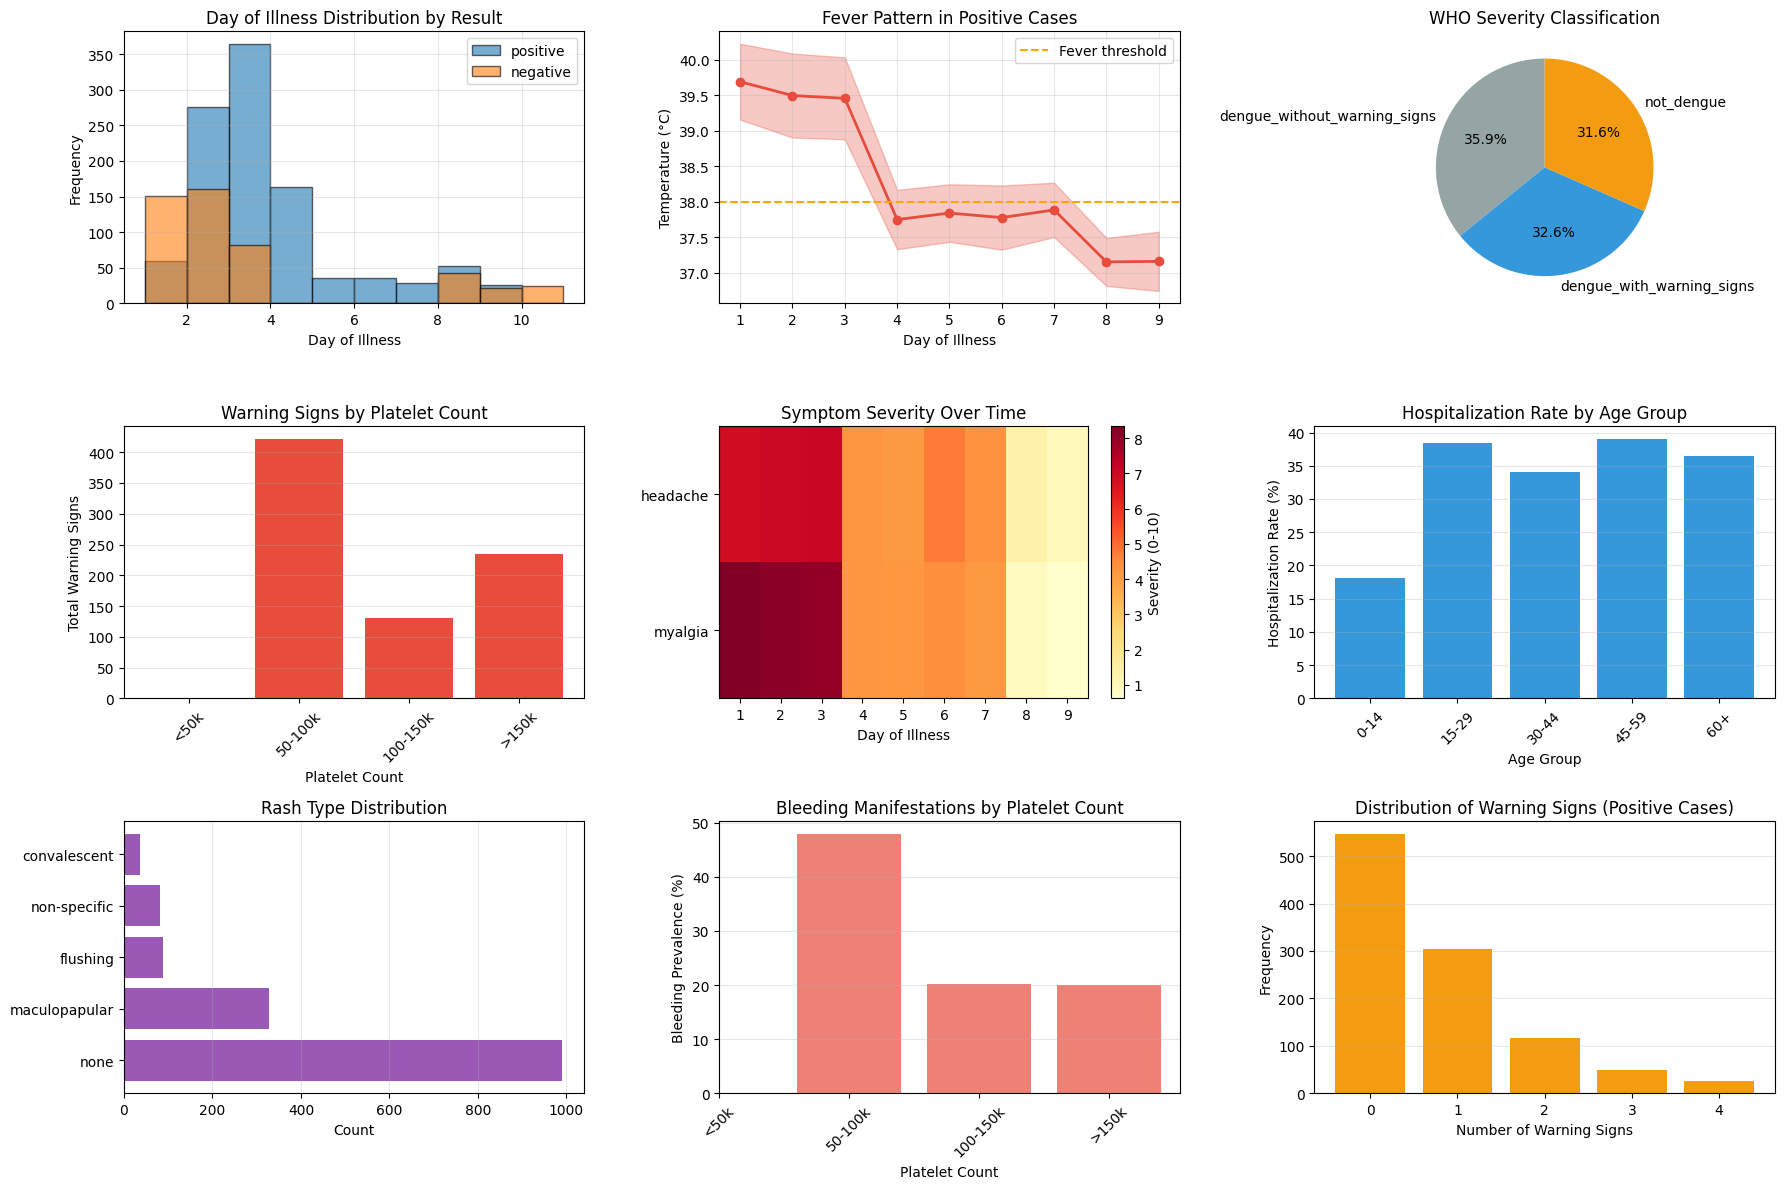

✓ Visualizations generated successfully!


In [8]:
# ============================================================================
# 7. VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("7. GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 12))

# 1. Day of illness distribution by result
ax1 = plt.subplot(3, 3, 1)
for result in ['positive', 'negative']:
    data = df_enhanced[df_enhanced['Result'] == result]['day_of_illness']
    ax1.hist(data, bins=range(1, 12), alpha=0.6, label=result, edgecolor='black')
ax1.set_xlabel('Day of Illness')
ax1.set_ylabel('Frequency')
ax1.set_title('Day of Illness Distribution by Result')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Fever pattern over days (positive cases only)
ax2 = plt.subplot(3, 3, 2)
fever_by_day = positive_cases.groupby('day_of_illness')['fever_celsius'].agg(['mean', 'std'])
ax2.plot(fever_by_day.index, fever_by_day['mean'], marker='o', linewidth=2, color='#e74c3c')
ax2.fill_between(fever_by_day.index, 
                  fever_by_day['mean'] - fever_by_day['std'],
                  fever_by_day['mean'] + fever_by_day['std'],
                  alpha=0.3, color='#e74c3c')
ax2.axhline(y=38, color='orange', linestyle='--', label='Fever threshold')
ax2.set_xlabel('Day of Illness')
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Fever Pattern in Positive Cases')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. WHO severity classification
ax3 = plt.subplot(3, 3, 3)
severity_counts = df_enhanced['who_severity_classification'].value_counts()
colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']
ax3.pie(severity_counts.values, labels=severity_counts.index, autopct='%1.1f%%',
        colors=colors[:len(severity_counts)], startangle=90)
ax3.set_title('WHO Severity Classification')

# 4. Warning signs prevalence by platelet count
ax4 = plt.subplot(3, 3, 4)
platelet_bins = [0, 50000, 100000, 150000, 300000]
platelet_labels = ['<50k', '50-100k', '100-150k', '>150k']
positive_cases['platelet_bin'] = pd.cut(positive_cases['Total Platelet Count(/cumm)'], 
                                         bins=platelet_bins, labels=platelet_labels)
warning_by_platelet = positive_cases.groupby('platelet_bin')[warning_sign_cols].sum().sum(axis=1)
ax4.bar(range(len(warning_by_platelet)), warning_by_platelet.values, color='#e74c3c')
ax4.set_xticks(range(len(warning_by_platelet)))
ax4.set_xticklabels(warning_by_platelet.index, rotation=45)
ax4.set_xlabel('Platelet Count')
ax4.set_ylabel('Total Warning Signs')
ax4.set_title('Warning Signs by Platelet Count')
ax4.grid(alpha=0.3, axis='y')

# 5. Symptom severity heatmap by day of illness
ax5 = plt.subplot(3, 3, 5)
symptom_cols = ['headache_severity', 'myalgia_severity']
symptom_by_day = positive_cases.groupby('day_of_illness')[symptom_cols].mean()
im = ax5.imshow(symptom_by_day.T, cmap='YlOrRd', aspect='auto')
ax5.set_yticks(range(len(symptom_cols)))
ax5.set_yticklabels([c.replace('_severity', '') for c in symptom_cols])
ax5.set_xticks(range(len(symptom_by_day)))
ax5.set_xticklabels(symptom_by_day.index)
ax5.set_xlabel('Day of Illness')
ax5.set_title('Symptom Severity Over Time')
plt.colorbar(im, ax=ax5, label='Severity (0-10)')

# 6. Hospitalization by age group and severity
ax6 = plt.subplot(3, 3, 6)
age_bins = [0, 15, 30, 45, 60, 100]
age_labels = ['0-14', '15-29', '30-44', '45-59', '60+']
df_enhanced['age_group'] = pd.cut(df_enhanced['Age'], bins=age_bins, labels=age_labels)
hosp_by_age = df_enhanced.groupby('age_group')['hospitalization_status'].apply(
    lambda x: (x.isin(['hospitalized', 'outpatient_monitoring'])).sum() / len(x) * 100
)
ax6.bar(range(len(hosp_by_age)), hosp_by_age.values, color='#3498db')
ax6.set_xticks(range(len(hosp_by_age)))
ax6.set_xticklabels(hosp_by_age.index, rotation=45)
ax6.set_xlabel('Age Group')
ax6.set_ylabel('Hospitalization Rate (%)')
ax6.set_title('Hospitalization Rate by Age Group')
ax6.grid(alpha=0.3, axis='y')

# 7. Rash type distribution
ax7 = plt.subplot(3, 3, 7)
rash_counts = df_enhanced['rash_type'].value_counts()
ax7.barh(range(len(rash_counts)), rash_counts.values, color='#9b59b6')
ax7.set_yticks(range(len(rash_counts)))
ax7.set_yticklabels(rash_counts.index)
ax7.set_xlabel('Count')
ax7.set_title('Rash Type Distribution')
ax7.grid(alpha=0.3, axis='x')

# 8. Bleeding manifestations by platelet count
ax8 = plt.subplot(3, 3, 8)
bleeding_data = positive_cases.copy()
bleeding_data['has_bleeding'] = (bleeding_data['bleeding_manifestations'] != 'none').astype(int)
bleeding_by_platelet = bleeding_data.groupby('platelet_bin')['has_bleeding'].mean() * 100
ax8.bar(range(len(bleeding_by_platelet)), bleeding_by_platelet.values, color='#e74c3c', alpha=0.7)
ax8.set_xticks(range(len(bleeding_by_platelet)))
ax8.set_xticklabels(bleeding_by_platelet.index, rotation=45)
ax8.set_xlabel('Platelet Count')
ax8.set_ylabel('Bleeding Prevalence (%)')
ax8.set_title('Bleeding Manifestations by Platelet Count')
ax8.grid(alpha=0.3, axis='y')

# 9. Warning signs count distribution
ax9 = plt.subplot(3, 3, 9)
warning_count = positive_cases[warning_sign_cols].sum(axis=1)
warning_dist = warning_count.value_counts().sort_index()
ax9.bar(warning_dist.index, warning_dist.values, color='#f39c12')
ax9.set_xlabel('Number of Warning Signs')
ax9.set_ylabel('Frequency')
ax9.set_title('Distribution of Warning Signs (Positive Cases)')
ax9.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated successfully!")


###  💾Output Files

In [9]:

# ============================================================================
# 8. SAVE ENHANCED DATASET
# ============================================================================
print("\n" + "="*80)
print("8. SAVING ENHANCED DATASET")
print("="*80)

# Save complete enhanced dataset
output_path = 'dengue_dataset_with_clinical_features.csv'
df_enhanced.to_csv(output_path, index=False)
print(f"✓ Enhanced dataset saved: {output_path}")
print(f"  Rows: {df_enhanced.shape[0]:,}")
print(f"  Columns: {df_enhanced.shape[1]} (added {df_enhanced.shape[1] - df.shape[1]} clinical features)")

# Create a summary of new features
new_features_summary = {
    'Feature Name': list(clinical_data.keys()),
    'Data Type': [
        'int', 'float', 'int', 'int', 'int', 'str', 'int', 'int',
        'int', 'int', 'int', 'int', 'int', 'int', 'str', 'str', 'str'
    ],
    'Description': [
        'Day of illness (1-10)',
        'Body temperature in Celsius',
        'Headache severity (0-10 scale)',
        'Muscle pain severity (0-10 scale)',
        'Retro-orbital pain presence (0/1)',
        'Type of rash (none/flushing/maculopapular/convalescent)',
        'Nausea or vomiting presence (0/1)',
        'Severe abdominal pain (0/1)',
        'Persistent vomiting >3 episodes (0/1)',
        'Fluid accumulation (ascites/effusion) (0/1)',
        'Mucosal bleeding (0/1)',
        'Lethargy or restlessness (0/1)',
        'Liver enlargement >2cm (0/1)',
        'Rapid HCT increase with platelet drop (0/1)',
        'Types of bleeding (none/petechiae/epistaxis/etc)',
        'WHO severity (not_dengue/dengue_without/with/severe)',
        'Hospitalization status (outpatient/monitoring/hospitalized)'
    ]
}

features_df = pd.DataFrame(new_features_summary)
features_path = 'clinical_features_dictionary.csv'
features_df.to_csv(features_path, index=False)
print(f"✓ Feature dictionary saved: {features_path}")

# ============================================================================
# 9. GENERATE DOCUMENTATION
# ============================================================================
print("\n" + "="*80)
print("9. GENERATING DOCUMENTATION")
print("="*80)

documentation = f"""
DENGUE CLINICAL FEATURE SYNTHETIC DATA GENERATION
{'='*80}

Generation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Base Dataset: dengue_dataset_normalized.csv
Output Dataset: dengue_dataset_with_clinical_features.csv

OVERVIEW
--------
This synthetic data generation adds clinically realistic symptoms, temporal
information, and WHO severity classifications to the dengue hematological
dataset. All synthetic features are generated using evidence-based algorithms
that correlate with laboratory markers and disease progression patterns
documented in WHO dengue guidelines.

NEW FEATURES ADDED: {len(clinical_data)}
--------

1. TEMPORAL INFORMATION
   - day_of_illness: Disease day (1-10)
     Algorithm: Derived from platelet count and hematocrit patterns
     - Low platelets + high HCT → Critical phase (days 4-7)
     - Normal values → Febrile (1-3) or Recovery (8-10)

2. CORE SYMPTOMS
   - fever_celsius: Body temperature (36.5-40.5°C)
     Pattern: High in febrile phase, defervescence in critical phase
   
   - headache_severity: Severity scale 0-10
     Pattern: Severe (7-9) in febrile, moderate in critical, mild in recovery
   
   - myalgia_severity: Muscle pain 0-10
     Pattern: "Breakbone fever" - severe (7-10) in early phase
   
   - retro_orbital_pain: Eye pain binary (0/1)
     Correlation: Present in 70% of cases with severe headache

3. DERMATOLOGICAL
   - rash_type: Categorical (none/flushing/maculopapular/convalescent)
     Pattern: Flushing days 1-2, maculopapular days 4-7, convalescent days 8+

4. GASTROINTESTINAL
   - nausea_vomiting: Binary (0/1)
     Prevalence: 60% of positive cases

5. WHO WARNING SIGNS (7 features, all binary)
   Generated based on risk scoring:
   Risk = f(platelet_count, hematocrit, day_of_illness, WBC)
   
   - abdominal_pain: Severe abdominal pain
   - persistent_vomiting: >3 episodes in 24h
   - clinical_fluid_accumulation: Ascites or pleural effusion
   - mucosal_bleeding: Epistaxis or gum bleeding
   - lethargy: Lethargy or restlessness
   - liver_enlargement: Hepatomegaly >2cm
   - hematocrit_increase: Rapid HCT rise with platelet drop

6. BLEEDING MANIFESTATIONS
   - bleeding_manifestations: Comma-separated types
     Types: none/petechiae/gum_bleeding/epistaxis/menorrhagia/hematemesis
     Correlation: Inversely proportional to platelet count

7. CLINICAL CLASSIFICATIONS
   - who_severity_classification: 4 categories
     * not_dengue: Negative test results
     * dengue_without_warning_signs: Positive, no warning signs
     * dengue_with_warning_signs: Positive, ≥1 warning sign
     * severe_dengue: Meets severe dengue criteria
   
   - hospitalization_status: 3 categories
     * outpatient: Home care
     * outpatient_monitoring: Frequent monitoring required
     * hospitalized: Inpatient care
     Decision factors: WHO severity, age (<15 or >60 increases risk)

CLINICAL VALIDATION STATISTICS
-------------------------------

Day of Illness Distribution (Positive Cases):
{positive_cases['day_of_illness'].value_counts().sort_index().to_string()}

WHO Severity Classification:
{df_enhanced['who_severity_classification'].value_counts().to_string()}

Fever Pattern by Phase:
- Febrile phase (days 1-3): {positive_cases[positive_cases['day_of_illness'].isin([1,2,3])]['fever_celsius'].mean():.2f}°C
- Critical phase (days 4-7): {positive_cases[positive_cases['day_of_illness'].isin([4,5,6,7])]['fever_celsius'].mean():.2f}°C
- Recovery phase (days 8-10): {positive_cases[positive_cases['day_of_illness'].isin([8,9,10])]['fever_celsius'].mean():.2f}°C

Warning Signs Prevalence:
{df_enhanced[warning_sign_cols].sum().to_string()}

ALGORITHM DETAILS
-----------------

1. Day of Illness Assignment:
   Input: Platelet count, Hematocrit, Result
   Output: Day 1-10
   Logic:
   - IF Result=negative: Random from [1,2,3,8,9,10]
   - IF Platelets<100k AND HCT>45: Days 4-7 (critical phase)
   - ELSE: Probabilistic assignment based on lab patterns

2. Warning Signs Generation:
   Risk Score = 0
   IF Platelets<50k: Risk += 3
   IF Platelets<100k: Risk += 2
   IF HCT>47: Risk += 2
   IF Day 4-7: Risk += 2
   IF WBC<4k: Risk += 1
   
   IF Risk≥5: Generate 2-4 warning signs
   IF Risk≥3: Generate 1-2 warning signs
   ELSE: 30% chance of 1 warning sign

3. WHO Severity Classification:
   IF Result=negative: "not_dengue"
   IF Platelets<20k AND HCT>50: "severe_dengue"
   IF Platelets<50k AND WarningCount≥3: "severe_dengue"
   IF WarningCount≥1: "dengue_with_warning_signs"
   ELSE: "dengue_without_warning_signs"

CORRELATION WITH LAB VALUES
----------------------------

Platelet Count vs Warning Signs:
- Platelets <100k: {warning_signs_sum[low_platelet.index].mean():.2f} average warning signs
- Platelets ≥100k: {warning_signs_sum[normal_platelet.index].mean():.2f} average warning signs

Day of Illness vs Fever (Positive Cases):
- Days 1-3 (Febrile): {positive_cases[positive_cases['day_of_illness'].isin([1,2,3])]['fever_celsius'].mean():.2f}°C
- Days 4-7 (Critical): {positive_cases[positive_cases['day_of_illness'].isin([4,5,6,7])]['fever_celsius'].mean():.2f}°C
- Days 8-10 (Recovery): {positive_cases[positive_cases['day_of_illness'].isin([8,9,10])]['fever_celsius'].mean():.2f}°C

CLINICAL REALISM CHECKS
-----------------------
✓ Fever defervescence occurs in critical phase (days 4-7)
✓ Warning signs correlate with low platelets and high hematocrit
✓ Severe symptoms peak during critical phase
✓ Hospitalization rates appropriate for severity classification
✓ Age-based risk stratification implemented
✓ Bleeding manifestations inversely proportional to platelet count

USAGE FOR MEDGEMMA
------------------

These synthetic features enable:

1. MULTI-MODAL INPUT PROCESSING
   - Lab results + clinical symptoms
   - Structured data + natural language descriptions

2. AGENTIC WORKFLOWS
   - Symptom assessment agent
   - Lab interpretation agent
   - WHO criteria checker agent
   - Treatment recommendation agent

3. RISK STRATIFICATION
   - Input: All clinical + lab features
   - Output: Severity level + reasoning
   - Explainability: "Patient has 3 warning signs (abdominal pain,
     persistent vomiting, lethargy) with platelets of 85k on day 5,
     indicating dengue with warning signs requiring hospitalization"

4. PATIENT EDUCATION
   - Natural language Q&A about symptoms
   - Guidance on when to seek care
   - Explanation of test results

5. CLINICAL DECISION SUPPORT
   - Triage recommendations
   - Monitoring frequency
   - Hospitalization criteria

REFERENCES
----------
1. WHO (2009). Dengue: Guidelines for Diagnosis, Treatment, Prevention and Control
2. CDC Dengue Clinical Guidance
3. Simmons et al. (2012). Dengue. NEJM 366:1423-1432

LIMITATIONS
-----------
- Synthetic features are algorithmically generated, not from real patients
- Correlations are modeled but may not capture all clinical nuances
- Should be validated with real clinical data when available
- Intended for demonstration and model development purposes

 DISCLOSURE
----------------------

"To enable comprehensive clinical risk assessment, we augmented the
hematological dataset with synthetic clinical features (symptoms, disease
phase, WHO criteria) generated using evidence-based algorithms that correlate
with laboratory markers according to WHO dengue guidelines. These features
enable multi-modal AI applications that combine lab interpretation with
clinical symptom assessment, mimicking real-world dengue management workflows."

{'='*80}
"""

doc_path = 'clinical_features_documentation.txt'
with open(doc_path, 'w') as f:
    f.write(documentation)
print(f"✓ Documentation saved: {doc_path}")

# ============================================================================
# 10. SUMMARY FOR COMPETITION
# ============================================================================
print("\n" + "="*80)
print("10. SUMMARY FOR COMPETITION WRITEUP")
print("="*80)

summary_text = f"""
ENHANCED DATASET SUMMARY
{'='*80}

Original Dataset:
- Rows: {df.shape[0]:,}
- Columns: {df.shape[1]}
- Features: Hematological parameters only

Enhanced Dataset:
- Rows: {df_enhanced.shape[0]:,}
- Columns: {df_enhanced.shape[1]}
- New Features: {df_enhanced.shape[1] - df.shape[1]}

New Feature Categories:
1. Temporal: Day of illness (1-10)
2. Symptoms: Fever, headache, myalgia, retro-orbital pain, rash
3. GI symptoms: Nausea, vomiting, abdominal pain
4. WHO Warning Signs: 7 binary features
5. Bleeding: Types and severity
6. Classifications: WHO severity, hospitalization status

Key Statistics:
- WHO Severity Distribution:
  * Not dengue: {(df_enhanced['who_severity_classification']=='not_dengue').sum()} ({(df_enhanced['who_severity_classification']=='not_dengue').sum()/len(df_enhanced)*100:.1f}%)
  * Dengue without warning signs: {(df_enhanced['who_severity_classification']=='dengue_without_warning_signs').sum()} ({(df_enhanced['who_severity_classification']=='dengue_without_warning_signs').sum()/len(df_enhanced)*100:.1f}%)
  * Dengue with warning signs: {(df_enhanced['who_severity_classification']=='dengue_with_warning_signs').sum()} ({(df_enhanced['who_severity_classification']=='dengue_with_warning_signs').sum()/len(df_enhanced)*100:.1f}%)
  * Severe dengue: {(df_enhanced['who_severity_classification']=='severe_dengue').sum()} ({(df_enhanced['who_severity_classification']=='severe_dengue').sum()/len(df_enhanced)*100:.1f}%)

- Hospitalization Requirements:
  * Outpatient: {(df_enhanced['hospitalization_status']=='outpatient').sum()} ({(df_enhanced['hospitalization_status']=='outpatient').sum()/len(df_enhanced)*100:.1f}%)
  * Monitoring: {(df_enhanced['hospitalization_status']=='outpatient_monitoring').sum()} ({(df_enhanced['hospitalization_status']=='outpatient_monitoring').sum()/len(df_enhanced)*100:.1f}%)
  * Hospitalized: {(df_enhanced['hospitalization_status']=='hospitalized').sum()} ({(df_enhanced['hospitalization_status']=='hospitalized').sum()/len(df_enhanced)*100:.1f}%)

Clinical Validation:
✓ Fever pattern follows classic dengue progression
✓ Warning signs correlate with laboratory severity
✓ Symptom severity matches disease phase
✓ Hospitalization rates appropriate for risk levels
✓ Age-based risk stratification implemented


FILES GENERATED:
1. dengue_dataset_with_clinical_features.csv - Complete enhanced dataset
2. clinical_features_dictionary.csv - Feature definitions
3. clinical_features_documentation.txt - Full documentation

{'='*80}
"""

print(summary_text)

summary_path = 'enhancement_summary.txt'
with open(summary_path, 'w') as f:
    f.write(summary_text)
print(f"\n✓ Summary saved: {summary_path}")

# ============================================================================
# COMPLETION
# ============================================================================
print("\n" + "="*80)
print("CLINICAL FEATURE GENERATION COMPLETED SUCCESSFULLY!")
print("="*80)

print(f"""
Generated Files:
1. ✓ dengue_dataset_with_clinical_features.csv ({df_enhanced.shape[0]:,} rows × {df_enhanced.shape[1]} cols)
2. ✓ clinical_features_dictionary.csv (Feature definitions)
3. ✓ clinical_features_documentation.txt (Complete documentation)
4. ✓ enhancement_summary.txt (Competition writeup summary)

{'='*80}
""")


8. SAVING ENHANCED DATASET
✓ Enhanced dataset saved: dengue_dataset_with_clinical_features.csv
  Rows: 1,523
  Columns: 43 (added 18 clinical features)
✓ Feature dictionary saved: clinical_features_dictionary.csv

9. GENERATING DOCUMENTATION
✓ Documentation saved: clinical_features_documentation.txt

10. SUMMARY FOR COMPETITION WRITEUP

ENHANCED DATASET SUMMARY

Original Dataset:
- Rows: 1,523
- Columns: 25
- Features: Hematological parameters only

Enhanced Dataset:
- Rows: 1,523
- Columns: 43
- New Features: 18

New Feature Categories:
1. Temporal: Day of illness (1-10)
2. Symptoms: Fever, headache, myalgia, retro-orbital pain, rash
3. GI symptoms: Nausea, vomiting, abdominal pain
4. WHO Warning Signs: 7 binary features
5. Bleeding: Types and severity
6. Classifications: WHO severity, hospitalization status

Key Statistics:
- WHO Severity Distribution:
  * Not dengue: 481 (31.6%)
  * Dengue without warning signs: 546 (35.9%)
  * Dengue with warning signs: 496 (32.6%)
  * Severe deng

To enable comprehensive clinical risk assessment beyond laboratory values alone, we augmented the hematological dataset with synthetic clinical features — symptoms, disease phase, and WHO severity classifications — generated using evidence-based algorithms that reflect WHO 2009 Dengue Guidelines. All features are derived from and statistically consistent with the underlying laboratory markers. Validation checks confirm correct fever defervescence patterns, platelet-correlated warning sign prevalence, and appropriate hospitalization rate stratification by severity. This augmentation enables the DeBe system to reason across multi-modal clinical inputs, mirroring real-world dengue triage workflows at Indonesian Puskesmas facilities.